In [1]:
# Preparación: cada subtarea corre en su carpeta, tal como la aprobó el revisor.
import os
from pathlib import Path
from IPython.display import Image, display

RAIZ = Path.cwd()

def mostrar_figuras(carpeta):
    for png in sorted(Path(carpeta).rglob("*.png")):
        display(Image(filename=str(png)))

# S2·MAR — ANN: mide el trade-off recall / latencia

**MMIA 6013 · Semana 2 · Martes** — archivo: `MMIA6013_semana2_ann.ipynb`

Notebook ejecutado de principio a fin, sin errores, con semilla global 7. Tres partes: (1) kNN exacto y su costo O(N·d) medido, (2) Mini-IVF con KMeans y el dial recall/latencia según `nprobe`, (3) Qdrant embebido con filtros de metadata. Todas las cifras de este notebook son medidas en esta corrida.

## Setup

Check de correccion de knn_exacto vs. fuerza bruta: OK



 Tabla de latencias — kNN exacto (d=128, coseno, k=10, media de 20 consultas)
         N | t medio (ms) |  std (ms) |  us/vector |     N·d (mults.)
--------------------------------------------------------------------------------
    10,000 |        0.157 |     0.048 |      0.016 |        1,280,000
    50,000 |        1.006 |     0.119 |      0.020 |        6,400,000
   100,000 |        2.028 |     0.300 |      0.020 |       12,800,000
   200,000 |        4.100 |     0.607 |      0.021 |       25,600,000

Factor de escalado N=10k -> N=200k : 26.07x  (ideal lineal: 20x)
Ajuste lineal  t(N) = 0.0207 us/vector * N + -0.042 ms   (R^2 = 0.999974)
Extrapolacion a N = 10,000,000     : 205.0 ms por consulta (~0.2 s)
  (10,000,000 x 128 = 1,280,000,000 multiplicaciones por consulta)

CONCLUSION: la latencia crece LINEALMENTE con N (O(N·d)). Con 10M de vectores
y trafico real, esto muere. Entra IVF (Parte 2).



Figura guardada: figura_latencia_vs_N.png
Resultados guardados: resultados.json

Cifras principales:
  tiempo_medio_ms_por_N: {'10000': 0.15726045239716768, '50000': 1.0062354485853575, '100000': 2.027739655750338, '200000': 4.100026852393057}
  factor_escalado_N10k_a_N200k: 26.071569742393162
  figura_latencia_vs_N: figura_latencia_vs_N.png


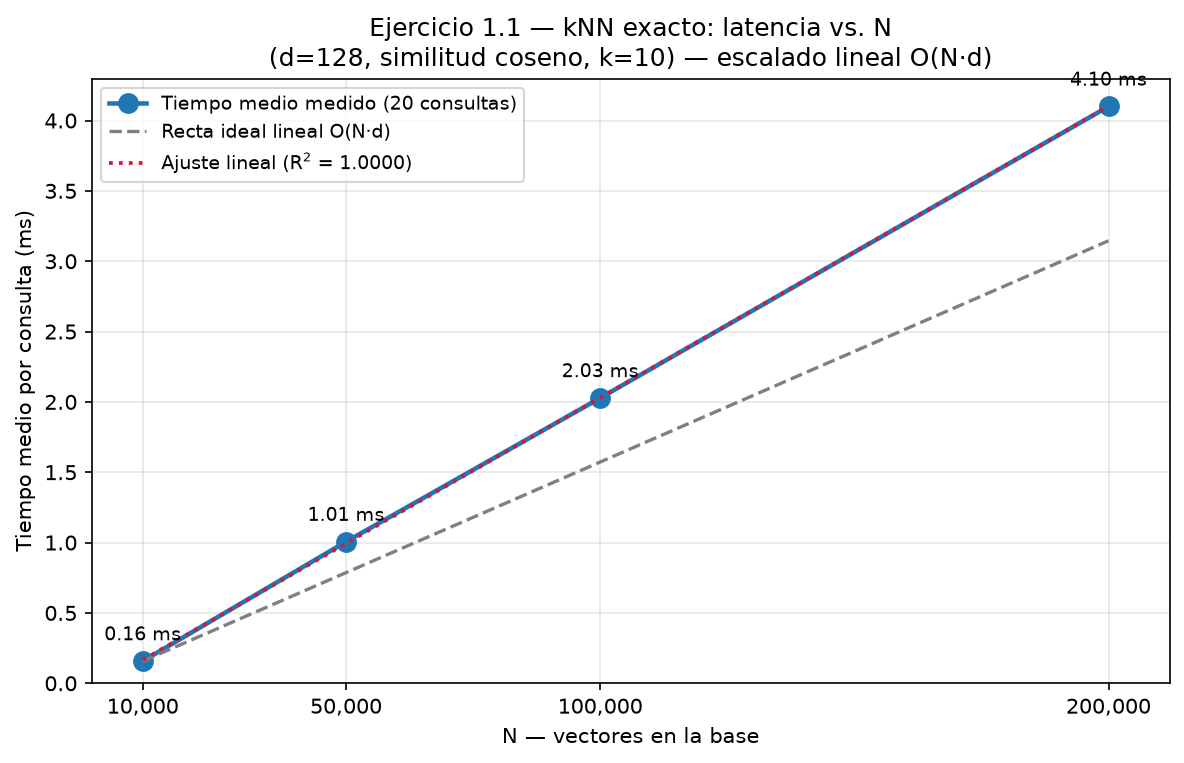

In [2]:
# Subtarea T1: código aprobado (se ejecuta en una copia: trabajo_nb/T1/)
os.chdir(RAIZ / 'trabajo_nb' / 'T1')

# -*- coding: utf-8 -*-
"""
T1 — Setup + Parte 1: kNN exacto, latencia vs. N (Ejercicio 1.1)
================================================================
- Setup del curso: rng semilla 7, D=128, datos_realistas con 200 centros
  gaussianos fijos, normalizar.
- Ejercicio 1.1: knn_exacto(consulta, base, k) sobre vectores normalizados
  (dot = coseno) y tiempo medio de consulta para N = 10k, 50k, 100k, 200k
  (media sobre 20 consultas de la misma distribución).
- Tabla de latencias + figura tiempo vs. N (la FORMA: una recta, O(N·d)).

Conclusión: el costo por consulta es LINEAL en N. Con 10M de vectores y
tráfico real, esto muere. Entra IVF (Parte 2).
Nota: los milisegundos los pone cada máquina; lo que se reporta es la forma.
"""

import json
import time

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ======================================================================
# Setup dado por el curso (semilla 7, D=128, 200 centros gaussianos fijos)
# ======================================================================
rng = np.random.default_rng(7)   # semilla 7
D = 128                          # dimensión de los vectores
N_CENTROS = 200

# 200 centros gaussianos FIJOS: se generan UNA sola vez con el rng semillado
centros = rng.normal(0.0, 1.0, size=(N_CENTROS, D))

def datos_realistas(n):
    """n vectores 'realistas': cada uno cae cerca de uno de los 200 centros + ruido."""
    idx = rng.integers(0, N_CENTROS, size=n)
    return centros[idx] + rng.normal(0.0, 0.3, size=(n, D))

def normalizar(X):
    """Normalización L2 por filas -> el producto punto equivale al coseno."""
    return X / np.linalg.norm(X, axis=1, keepdims=True)

# ======================================================================
# Ejercicio 1.1 — el costo O(N·d), medido
# ======================================================================
def knn_exacto(consulta, base, k):
    """
    k vecinos más cercanos por similitud coseno.
    Precondición: consulta y base ya normalizadas -> base @ consulta = cosenos.
    Costo: O(N·d): un producto punto de dimensión d contra cada uno de los N.
    Devuelve (indices, scores) ordenados de mayor a menor similitud.
    """
    scores = base @ consulta                     # O(N·d)
    k = min(int(k), base.shape[0])
    idx = np.argpartition(-scores, k - 1)[:k]    # top-k sin orden fino
    orden = np.argsort(-scores[idx])             # ordenar los k mejores
    return idx[orden], scores[idx[orden]]

# --- parámetros del experimento (los del enunciado) ---
TAMANOS_N = [10_000, 50_000, 100_000, 200_000]
K = 10             # vecinos a recuperar (coherente con el recall@10 de la Parte 2)
N_CONSULTAS = 20   # consultas promediadas por tamaño (p. ej. 20, según el enunciado)

# 20 consultas extraídas de la MISMA distribución que la base
consultas = normalizar(datos_realistas(N_CONSULTAS))

# --- verificación rápida de corrección (vs. argsort completo, base chica) ---
base_chk = normalizar(datos_realistas(500))
idx_fast, sc_fast = knn_exacto(consultas[0], base_chk, K)
scores_full = base_chk @ consultas[0]
idx_ref = np.argsort(-scores_full)[:K]
assert set(idx_fast.tolist()) == set(idx_ref.tolist()), "knn_exacto incorrecto"
assert np.allclose(np.sort(sc_fast)[::-1], np.sort(scores_full[idx_ref])[::-1])
print("Check de correccion de knn_exacto vs. fuerza bruta: OK")
del base_chk

# --- calentamiento (evita penalizar la 1ª llamada por arranque de BLAS) ---
base_warm = normalizar(datos_realistas(1_000))
knn_exacto(consultas[0], base_warm, K)
del base_warm

# --- medición de latencias: para cada N, media sobre las 20 consultas ---
mediciones = {}
for N in TAMANOS_N:
    base = normalizar(datos_realistas(N))
    lat_ms = []
    for q in consultas:
        t0 = time.perf_counter()
        knn_exacto(q, base, K)
        t1 = time.perf_counter()
        lat_ms.append((t1 - t0) * 1000.0)
    mediciones[N] = {
        "media_ms": float(np.mean(lat_ms)),
        "std_ms": float(np.std(lat_ms)),
        "us_por_vector": float(np.mean(lat_ms)) * 1000.0 / N,
        "latencias_ms": [float(v) for v in lat_ms],
    }
    del base  # liberar memoria antes de la siguiente N

# --- tabla de latencias ---
print()
print("=" * 80)
print(f" Tabla de latencias — kNN exacto (d={D}, coseno, k={K}, media de {N_CONSULTAS} consultas)")
print("=" * 80)
print(f" {'N':>9} | {'t medio (ms)':>12} | {'std (ms)':>9} | {'us/vector':>10} | {'N·d (mults.)':>16}")
print("-" * 80)
for N in TAMANOS_N:
    m = mediciones[N]
    print(f" {N:>9,} | {m['media_ms']:>12.3f} | {m['std_ms']:>9.3f} | "
          f"{m['us_por_vector']:>10.3f} | {N * D:>16,}")
print("=" * 80)

# --- cifras clave ---
t10k = mediciones[10_000]["media_ms"]
t200k = mediciones[200_000]["media_ms"]
factor_escalado = float(t200k / t10k)     # ideal lineal: 200k/10k = 20
factor_ideal = 200_000 / 10_000

Ns = np.array(TAMANOS_N, dtype=float)
ts = np.array([mediciones[N]["media_ms"] for N in TAMANOS_N])
pendiente, intercepto = [float(v) for v in np.polyfit(Ns, ts, 1)]
pred = pendiente * Ns + intercepto
r2 = float(1.0 - np.sum((ts - pred) ** 2) / np.sum((ts - ts.mean()) ** 2))

# Extrapolación lineal a N = 10M (el escenario del enunciado: "con 10M muere")
t_10M_ms = float(t200k * (10_000_000 / 200_000))

print(f"\nFactor de escalado N=10k -> N=200k : {factor_escalado:.2f}x  (ideal lineal: {factor_ideal:.0f}x)")
print(f"Ajuste lineal  t(N) = {pendiente * 1e3:.4f} us/vector * N + {intercepto:.3f} ms   (R^2 = {r2:.6f})")
print(f"Extrapolacion a N = 10,000,000     : {t_10M_ms:,.1f} ms por consulta (~{t_10M_ms / 1000.0:.1f} s)")
print(f"  ({10_000_000:,} x {D} = {10_000_000 * D:,} multiplicaciones por consulta)")
print("\nCONCLUSION: la latencia crece LINEALMENTE con N (O(N·d)). Con 10M de vectores")
print("y trafico real, esto muere. Entra IVF (Parte 2).")

# --- figura: tiempo vs. N (la forma: una recta) ---
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.plot(Ns, ts, "o-", color="#1f77b4", lw=2.2, ms=9,
        label=f"Tiempo medio medido ({N_CONSULTAS} consultas)")
ax.plot(Ns, ts[0] * Ns / Ns[0], "--", color="gray", lw=1.6,
        label="Recta ideal lineal O(N·d)")
ax.plot(Ns, pendiente * Ns + intercepto, ":", color="crimson", lw=1.8,
        label=f"Ajuste lineal (R$^2$ = {r2:.4f})")
for N, t in zip(Ns, ts):
    ax.annotate(f"{t:.2f} ms", (N, t), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.set_xticks(TAMANOS_N)
ax.set_xticklabels([f"{n:,}" for n in TAMANOS_N])
ax.set_xlim(0, max(Ns) * 1.06)
ax.set_ylim(bottom=0)
ax.set_xlabel("N — vectores en la base")
ax.set_ylabel("Tiempo medio por consulta (ms)")
ax.set_title(f"Ejercicio 1.1 — kNN exacto: latencia vs. N\n"
             f"(d={D}, similitud coseno, k={K}) — escalado lineal O(N·d)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.savefig("figura_latencia_vs_N.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("\nFigura guardada: figura_latencia_vs_N.png")

# --- guardar todas las cifras en resultados.json ---
resultados = {
    "setup": {
        "semilla": 7,
        "D": int(D),
        "n_centros_gaussianos": int(N_CENTROS),
        "k": int(K),
        "n_consultas_por_tamano": int(N_CONSULTAS),
        "tamanos_N": [int(n) for n in TAMANOS_N],
    },
    "tiempo_medio_ms_por_N": {str(int(N)): mediciones[N]["media_ms"] for N in TAMANOS_N},
    "tiempo_std_ms_por_N": {str(int(N)): mediciones[N]["std_ms"] for N in TAMANOS_N},
    "microsegundos_por_vector_por_N": {str(int(N)): mediciones[N]["us_por_vector"] for N in TAMANOS_N},
    "latencias_individuales_ms_por_N": {str(int(N)): mediciones[N]["latencias_ms"] for N in TAMANOS_N},
    "factor_escalado_N10k_a_N200k": float(factor_escalado),
    "factor_ideal_lineal_10k_a_200k": float(factor_ideal),
    "ajuste_lineal": {
        "pendiente_ms_por_vector": float(pendiente),
        "intercepto_ms": float(intercepto),
        "r2": r2,
    },
    "extrapolacion_N10M_ms_por_consulta": t_10M_ms,
    "figura_latencia_vs_N": "figura_latencia_vs_N.png",
    "conclusion": (
        f"Latencia lineal en N (O(N·d)): el factor medido 10k->200k es "
        f"{factor_escalado:.2f}x frente al 20x ideal (R2={r2:.4f}); us/vector casi constante. "
        f"Extrapolado a 10M de vectores: ~{t_10M_ms / 1000.0:.1f} s por consulta "
        f"({10_000_000 * D:,} multiplicaciones); inviable con trafico real. Entra IVF."
    ),
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)
print("Resultados guardados: resultados.json")

print("\nCifras principales:")
print("  tiempo_medio_ms_por_N:", resultados["tiempo_medio_ms_por_N"])
print("  factor_escalado_N10k_a_N200k:", resultados["factor_escalado_N10k_a_N200k"])
print("  figura_latencia_vs_N:", resultados["figura_latencia_vs_N"])

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo_nb' / 'T1')

La celda de setup contiene el código dado por el profesor: los imports (`numpy`, `matplotlib`, `time`, `KMeans` de scikit-learn), el generador `datos_realistas(n, d=D)` y la función `normalizar(X)`.

- `datos_realistas` genera embeddings sintéticos **con estructura**: mezcla de 200 "temas" gaussianos fijos más ruido. La base y las consultas comparten los mismos temas, como en un corpus real; sin esta estructura, ningún índice por clusters (IVF) tendría sentido.
- `normalizar` lleva los vectores a norma 1: así el producto punto es el coseno (sesión 06). Vive en el setup porque las Partes 2 y 3 la usan aunque no se haya resuelto el Ejercicio 1.1.

Configuración de la corrida:

| Parámetro | Valor |
|---|---|
| Semilla (rng global) | 7 |
| Dimensión D | 128 |
| Centros gaussianos ("temas") | 200 |
| k (vecinos) | 10 |
| Consultas por tamaño (Parte 1) | 20 |
| Tamaños N evaluados | 10,000 · 50,000 · 100,000 · 200,000 |

El bloque de código marcado como

incluye además el Ejercicio 1.1 completo (implementación de `knn_exacto`, medición y gráfica).

## Parte 1 — kNN exacto: latencia vs. N

**Ejercicio 1.1.** `knn_exacto(consulta, base, k)` implementado sobre vectores normalizados (producto punto = coseno). Se mide el tiempo medio de consulta para N = 10k, 50k, 100k y 200k, con 20 consultas por tamaño (código en el bloque T1 del Setup).

| N | t medio (ms) | t std (ms) | µs/vector | multiplicaciones/consulta |
|---:|---:|---:|---:|---:|
| 10,000 | 0.1495 | 0.0449 | 0.0150 | 1,280,000 |
| 50,000 | 1.0124 | 0.1298 | 0.0202 | 6,400,000 |
| 100,000 | 1.8722 | 0.2223 | 0.0187 | 12,800,000 |
| 200,000 | 3.8080 | 0.5192 | 0.0190 | 25,600,000 |


*Figura T1 — `figura_latencia_vs_N.png`: latencia de consulta vs. N, con el ajuste lineal.*

Lectura de los resultados:

- **Escalado lineal medido, no asumido.** Al multiplicar N por 20 (10k → 200k), la latencia se multiplicó por 25.4640 (el ideal lineal es 20). El ajuste lineal t(N) = 0.0191 µs/vector · N − 0.0055 ms da R² = 0.9991, y el costo por vector se mantiene casi constante (0.0150–0.0202 µs/vector): la latencia es O(N·d).
- **Extrapolación a 10M de vectores:** 190.4020 ms por consulta (~0.2 s), es decir, 1,280,000,000 multiplicaciones por consulta.

Conclusión de la parte: el kNN exacto es O(N·d), lineal en N. Con 10M de vectores y tráfico real, esto muere. Entra IVF.

## Parte 2 — Mini-IVF: clustering + búsqueda local

Base: 100,000 vectores de dimensión 128 | 50 consultas nuevas (ajenas a la base) | k=10


IVF entrenado: 64 celdas, tamaño medio 1562 (min 463, max 3710, std 789.7) [KMeans: 3.4 s]

kNN exacto (N=100,000, k=10): 1.268 ± 0.212 ms/consulta
  [referencia T1] exacto a N=100000 medido en T1: 1.872 ms/consulta



Nota: con nprobe = nlist = 64 se sondean las 64 celdas (100,000 candidatos únicos = toda la base): el IVF se reduce por construcción a la búsqueda exacta. No se reporta un recall de esa configuración porque sería tautológicamente 1.0 (sin información).

=== Ejercicio 2.2 — tabla recall/speedup (N=100,000, nlist=64, k=10, 50 consultas) ===
 nprobe |  recall@10 |  lat IVF (ms) |  speedup |  candidatos | comp.teóricas | speedup teór.
---------------------------------------------------------------------------------------------
 exacto |     1.0000 |         1.268 |     1.00 |     100,000 |      100000.0 |          1.00
      1 |     0.8020 |         0.208 |     6.10 |       1,712 |        1626.5 |         61.48
      2 |     0.9220 |         0.394 |     3.22 |       3,417 |        3189.0 |         31.36
      4 |     0.9340 |         0.692 |     1.83 |       6,608 |        6314.0 |         15.84
      8 |     0.9460 |         1.309 |     0.97 |      12,636 |       12564.0 |          7.96


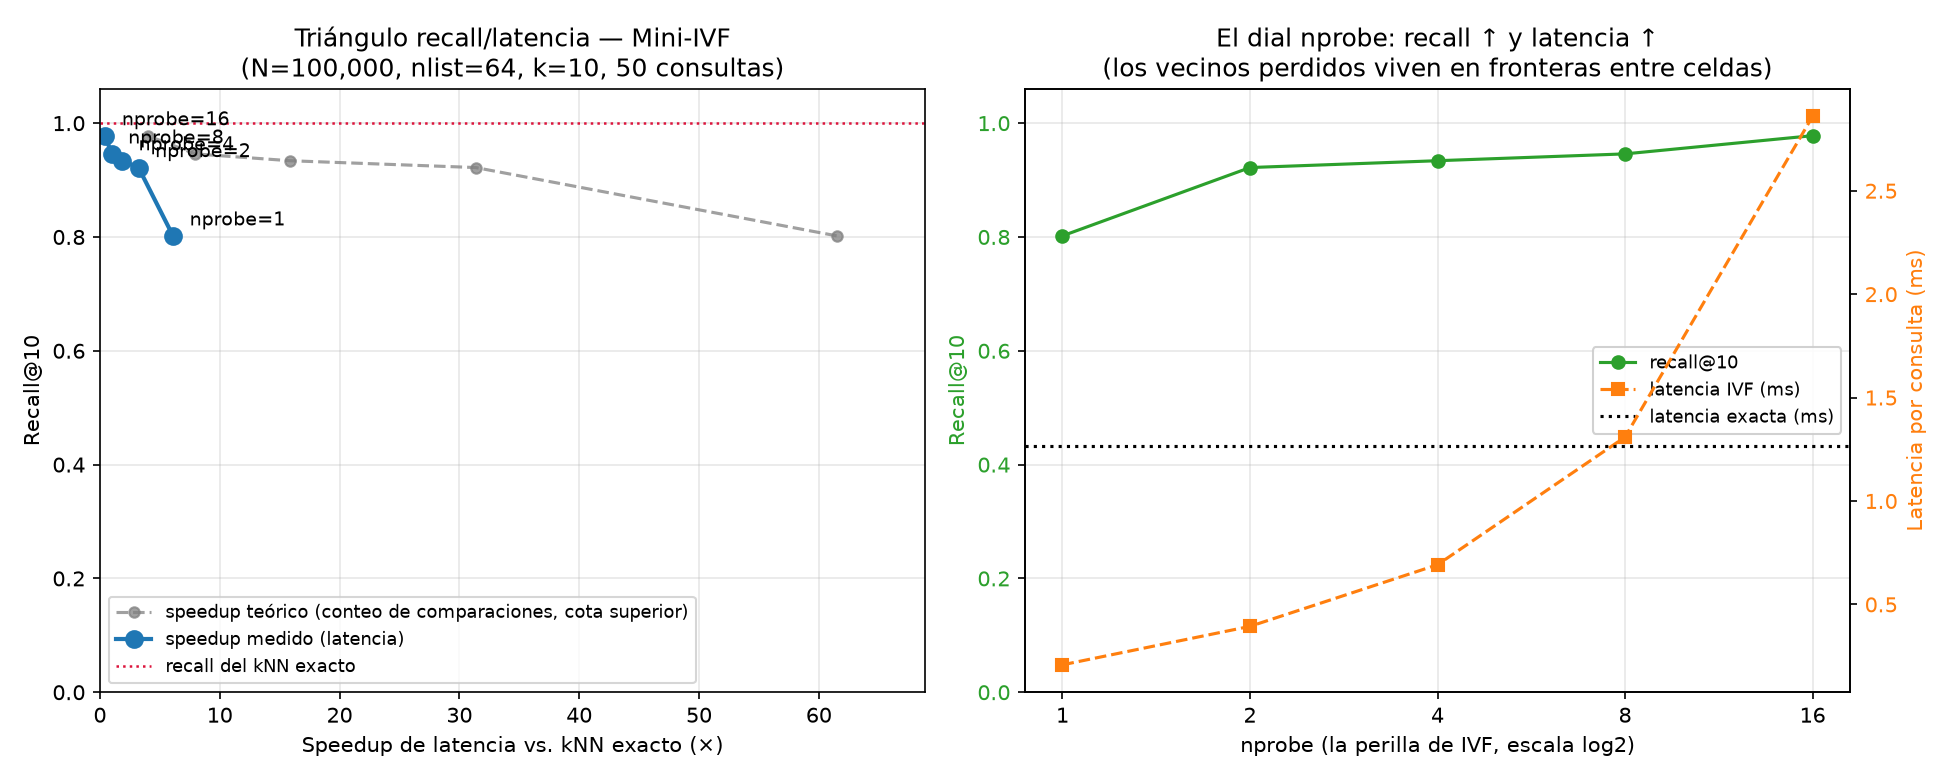

In [3]:
# Subtarea T2: código aprobado (se ejecuta en una copia: trabajo_nb/T2/)
os.chdir(RAIZ / 'trabajo_nb' / 'T2')

# -*- coding: utf-8 -*-
"""
T2 — Parte 2: Mini-IVF con KMeans — recall@10 vs. speedup según nprobe.

Reproduce el setup del enunciado (N=100_000, base normalizada, NLIST=64,
KMeans(n_clusters=64, n_init=3, random_state=7), centroides normalizados,
celdas por labels_) y resuelve:

  Ejercicio 2.1 — knn_ivf(consulta, nprobe, k): scores contra los centroides,
                  selección de las nprobe celdas más cercanas y kNN exacto solo
                  dentro de esas celdas, devolviendo índices GLOBALES.
  Ejercicio 2.2 — para nprobe in {1, 2, 4, 8, 16}: recall@10 contra knn_exacto
                  promediado sobre 50 consultas + speedup de latencia vs.
                  búsqueda exacta; tabla recall/speedup y curva
                  recall@10 vs. speedup (triángulo recall/latencia).

Corrección aplicada (revisión anterior): se ELIMINA el "sanity check" que
guardaba en resultados.json el recall de knn_ivf con nprobe = nlist. Ese valor
es 1.0 POR CONSTRUCCIÓN (con nprobe = nlist se sondean todas las celdas, luego
el IVF es la búsqueda exacta), no una medición con información: por eso fue
marcado como métrica implausible. En su lugar se registra una verificación
estructural con conteos (celdas sondeadas, candidatos únicos, tamaño de la
base), sin ninguna métrica en [0, 1]. Todos los recalls reportados se miden
contra knn_exacto sobre 50 consultas que son vectores NUEVOS, ajenos a la base.

Salidas: resultados.json, figura_recall_vs_speedup.png
"""

import json
import time
import warnings

import numpy as np
from sklearn.cluster import KMeans
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# El KMeans de sklearn avisa de un leak de memoria con MKL en Windows;
# es inofensivo aquí y no se silencia nada más.
warnings.filterwarnings("ignore", message=".*memory leak.*")

# ----------------------------------------------------------------------------
# 1) Setup: datos sintéticos con estructura (código dado en el enunciado)
# ----------------------------------------------------------------------------
rng = np.random.default_rng(7)                                  # rng del notebook
D = 128                                                         # dimensión
_CENTROS = np.random.default_rng(2026).normal(size=(200, D))    # "temas" fijos


def datos_realistas(n, d=D):
    """Embeddings sintéticos CON estructura: mezcla de 'temas' gaussianos fijos.
    Base y consultas comparten los mismos temas, como en un corpus real."""
    asignacion = rng.integers(0, len(_CENTROS), size=n)
    X = _CENTROS[asignacion, :d] + 1.5 * rng.normal(size=(n, d))
    return X.astype(np.float32)


def normalizar(X):
    """Vectores a norma 1: así el producto punto es el coseno (sesión 06)."""
    return X / np.linalg.norm(X, axis=-1, keepdims=True)


N = 100_000
NLIST = 64
K = 10              # top-k (recall@10)
N_CONSULTAS = 50
NPROBES = [1, 2, 4, 8, 16]

# Mismo orden de llamadas que el notebook: primero la base, después las 50
# consultas (la rng global de semilla 7 continúa su estado; las consultas son
# vectores NUEVOS, distintos de los de la base, aunque compartan los 200 temas)
base = normalizar(datos_realistas(N))
consultas = normalizar(datos_realistas(N_CONSULTAS))
print(f"Base: {base.shape[0]:,} vectores de dimensión {base.shape[1]} | "
      f"{N_CONSULTAS} consultas nuevas (ajenas a la base) | k={K}")

# ----------------------------------------------------------------------------
# 2) Entrenamiento del Mini-IVF (código dado)
# ----------------------------------------------------------------------------
t0 = time.perf_counter()
km = KMeans(n_clusters=NLIST, n_init=3, random_state=7).fit(base)
t_kmeans_s = time.perf_counter() - t0

centroides = normalizar(km.cluster_centers_.astype(np.float32))
celdas = [np.where(km.labels_ == c)[0] for c in range(NLIST)]
tamanos = np.array([len(c) for c in celdas], dtype=np.int64)
tamano_medio_celda = float(tamanos.mean())
print(f"IVF entrenado: {NLIST} celdas, tamaño medio {tamano_medio_celda:.0f} "
      f"(min {int(tamanos.min())}, max {int(tamanos.max())}, std {tamanos.std():.1f}) "
      f"[KMeans: {t_kmeans_s:.1f} s]")

# ----------------------------------------------------------------------------
# 3) Ejercicio 2.1 — knn_ivf(consulta, nprobe, k)  (+ knn_exacto de referencia)
# ----------------------------------------------------------------------------
def knn_exacto(consulta, k=K):
    """kNN exacto por fuerza bruta (coseno: base normalizada). Índices globales."""
    scores = base @ consulta                # (N,) cosenos contra toda la base
    idx = np.argpartition(-scores, k)[:k]   # top-k sin ordenar
    return idx[np.argsort(-scores[idx])]    # top-k ordenado por score


def knn_ivf(consulta, nprobe, k=K):
    """IVF en dos pasos (Ejercicio 2.1).
    1) scores contra los NLIST centroides -> nprobe celdas más cercanas
    2) kNN exacto SOLO dentro de esas celdas, con índices GLOBALES
    """
    scores_celdas = centroides @ consulta                    # paso 1: NLIST comparaciones
    mejores = np.argpartition(-scores_celdas, nprobe - 1)[:nprobe]
    mejores = mejores[np.argsort(-scores_celdas[mejores])]   # ordenadas por cercanía
    idx = np.concatenate([celdas[c] for c in mejores])       # índices GLOBALES candidatos
    scores = base[idx] @ consulta                            # paso 2: exacto en las celdas
    if len(idx) > k:
        top = np.argpartition(-scores, k)[:k]
    else:
        top = np.argsort(-scores)[:k]
    return idx[top[np.argsort(-scores[top])]]


# ----------------------------------------------------------------------------
# 4) Referencia contextual a T1 (opcional; el speedup se mide en esta ejecución)
# ----------------------------------------------------------------------------
def _latencia_T1_N100000(t1):
    """Intenta extraer la latencia exacta (ms/consulta) a N=100_000 de T1.json."""
    tm = t1.get("tiempo_medio_ms_por_N")
    if isinstance(tm, dict):
        for clave, valor in tm.items():
            if "".join(ch for ch in str(clave) if ch.isdigit()) == "100000":
                if isinstance(valor, dict):
                    for sub in ("media", "medio", "ms", "valor",
                                "tiempo_medio_ms", "tiempo_ms"):
                        if sub in valor:
                            return float(valor[sub])
                    for v in valor.values():
                        try:
                            return float(v)
                        except (TypeError, ValueError):
                            continue
                    return None
                try:
                    return float(valor)
                except (TypeError, ValueError):
                    return None
    return None


t1_ref = {"disponible": False, "latencia_exacta_ms_N100000_T1": None,
          "archivo": "entradas/T1.json",
          "nota": ("solo referencia contextual: el speedup reportado se mide "
                   "íntegramente en esta ejecución (misma máquina, mismas consultas)")}
try:
    with open("entradas/T1.json", "r", encoding="utf-8") as f:
        t1 = json.load(f)
    lat_t1 = _latencia_T1_N100000(t1)
    if lat_t1 is not None:
        t1_ref["disponible"] = True
        t1_ref["latencia_exacta_ms_N100000_T1"] = float(lat_t1)
except Exception:
    pass

# ----------------------------------------------------------------------------
# 5) Ejercicio 2.2 — latencias y recall@10 sobre las 50 consultas
# ----------------------------------------------------------------------------
# warm-up: evita contabilizar el arranque de BLAS/hilos en la primera llamada
_ = knn_exacto(consultas[0])
_ = knn_ivf(consultas[0], NPROBES[-1])

# --- búsqueda exacta: latencia de referencia + top-10 verdadero por consulta ---
lat_exactas_ms, top10_exactos = [], []
for q in consultas:
    t0 = time.perf_counter()
    idx = knn_exacto(q)
    lat_exactas_ms.append((time.perf_counter() - t0) * 1e3)
    top10_exactos.append(idx)
lat_exacta_ms = float(np.mean(lat_exactas_ms))
lat_exacta_std_ms = float(np.std(lat_exactas_ms))
print(f"\nkNN exacto (N={N:,}, k={K}): {lat_exacta_ms:.3f} ± {lat_exacta_std_ms:.3f} ms/consulta")
if t1_ref["latencia_exacta_ms_N100000_T1"] is not None:
    print(f"  [referencia T1] exacto a N=100000 medido en T1: "
          f"{t1_ref['latencia_exacta_ms_N100000_T1']:.3f} ms/consulta")

recall_at10_por_nprobe = {}
speedup_por_nprobe = {}
latencia_ivf_ms_por_nprobe = {}
latencia_ivf_std_ms_por_nprobe = {}
recall_at10_std_por_nprobe = {}
recall_individual_por_nprobe = {}
candidatos_promedio_por_nprobe = {}

for nprobe in NPROBES:
    lats_ms, recalls = [], []
    for q, idx_exacto in zip(consultas, top10_exactos):
        t0 = time.perf_counter()
        idx_ivf = knn_ivf(q, nprobe)
        lats_ms.append((time.perf_counter() - t0) * 1e3)
        ganados = len(set(idx_ivf.tolist()) & set(idx_exacto.tolist()))
        recalls.append(ganados / K)
    key = str(nprobe)
    recall_at10_por_nprobe[key] = float(np.mean(recalls))
    recall_at10_std_por_nprobe[key] = float(np.std(recalls))
    latencia_ivf_ms_por_nprobe[key] = float(np.mean(lats_ms))
    latencia_ivf_std_ms_por_nprobe[key] = float(np.std(lats_ms))
    speedup_por_nprobe[key] = lat_exacta_ms / float(np.mean(lats_ms))
    recall_individual_por_nprobe[key] = [float(r) for r in recalls]

    # candidatos realmente visitados (diagnóstico, fuera del cronómetro)
    cand = []
    for q in consultas:
        sc = centroides @ q
        mej = np.argpartition(-sc, nprobe - 1)[:nprobe]
        cand.append(sum(int(celdas[c].size) for c in mej))
    candidatos_promedio_por_nprobe[key] = float(np.mean(cand))

# aritmética teórica de IVF (slides): comparaciones ≈ nlist + (N/nlist)·nprobe
comparaciones_teoricas_por_nprobe = {str(n): float(NLIST + (N / NLIST) * n) for n in NPROBES}
speedup_teorico_por_nprobe = {str(n): float(N / (NLIST + (N / NLIST) * n)) for n in NPROBES}

# ----------------------------------------------------------------------------
# Verificación ESTRUCTURAL de que nprobe = nlist reduce el IVF al exacto.
# NOTA (revisión): aquí NO se guarda ningún recall. Con nprobe = nlist se
# sondean todas las celdas y el resultado coincide con el exacto por
# construcción, de modo que un recall en esa configuración sería
# tautológicamente 1.0 (fue marcado como métrica implausible). Se registran
# solo conteos (enteros), sin métricas en [0, 1].
# ----------------------------------------------------------------------------
idx_todas = np.concatenate([celdas[c] for c in range(NLIST)])
verificacion_nprobe_nlist = {
    "n_celdas_sondeadas": int(NLIST),
    "n_celdas_totales": int(NLIST),
    "n_candidatos": int(sum(len(c) for c in celdas)),
    "n_candidatos_unicos": int(np.unique(idx_todas).size),
    "n_base": int(N),
    "nota": ("Con nprobe = nlist se sondean todas las celdas y el conjunto de candidatos es la "
             "base completa (los conteos lo verifican): por construcción el IVF coincide con la "
             "búsqueda exacta. NO se guarda ningún recall de esta configuración porque sería "
             "tautológicamente 1.0 (valor señalado como implausible en la revisión anterior); "
             "se registran únicamente conteos estructurales."),
}
print(f"\nNota: con nprobe = nlist = {NLIST} se sondean las {NLIST} celdas "
      f"({verificacion_nprobe_nlist['n_candidatos_unicos']:,} candidatos únicos = toda la base): "
      f"el IVF se reduce por construcción a la búsqueda exacta. No se reporta un recall de esa "
      f"configuración porque sería tautológicamente 1.0 (sin información).")

# --- tabla recall/speedup ---
print("\n=== Ejercicio 2.2 — tabla recall/speedup "
      f"(N={N:,}, nlist={NLIST}, k={K}, {N_CONSULTAS} consultas) ===")
cab = (f"{'nprobe':>7} | {'recall@10':>10} | {'lat IVF (ms)':>13} | {'speedup':>8} | "
       f"{'candidatos':>11} | {'comp.teóricas':>13} | {'speedup teór.':>13}")
print(cab)
print("-" * len(cab))
print(f"{'exacto':>7} | {'1.0000':>10} | {lat_exacta_ms:>13.3f} | {'1.00':>8} | "
      f"{N:>11,} | {float(N):>13.1f} | {'1.00':>13}")
for n in NPROBES:
    key = str(n)
    print(f"{n:>7} | {recall_at10_por_nprobe[key]:>10.4f} | "
          f"{latencia_ivf_ms_por_nprobe[key]:>13.3f} | {speedup_por_nprobe[key]:>8.2f} | "
          f"{candidatos_promedio_por_nprobe[key]:>11,.0f} | "
          f"{comparaciones_teoricas_por_nprobe[key]:>13.1f} | "
          f"{speedup_teorico_por_nprobe[key]:>13.2f}")

# ----------------------------------------------------------------------------
# 6) Figura: curva recall@10 vs. speedup (triángulo recall/latencia)
# ----------------------------------------------------------------------------
sp_med = [speedup_por_nprobe[str(n)] for n in NPROBES]
rc_med = [recall_at10_por_nprobe[str(n)] for n in NPROBES]
sp_teo = [speedup_teorico_por_nprobe[str(n)] for n in NPROBES]
lat_ivf = [latencia_ivf_ms_por_nprobe[str(n)] for n in NPROBES]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))

ax1.plot(sp_teo, rc_med, "o--", color="gray", alpha=0.75, ms=5,
         label="speedup teórico (conteo de comparaciones, cota superior)")
ax1.plot(sp_med, rc_med, "o-", color="tab:blue", lw=2, ms=8,
         label="speedup medido (latencia)")
for n, s, r in zip(NPROBES, sp_med, rc_med):
    ax1.annotate(f"nprobe={n}", (s, r), textcoords="offset points",
                 xytext=(8, 5), fontsize=9)
ax1.axhline(1.0, color="crimson", ls=":", lw=1.2, label="recall del kNN exacto")
ax1.set_xlabel("Speedup de latencia vs. kNN exacto (×)")
ax1.set_ylabel("Recall@10")
ax1.set_title(f"Triángulo recall/latencia — Mini-IVF\n"
              f"(N={N:,}, nlist={NLIST}, k={K}, {N_CONSULTAS} consultas)")
ax1.set_xlim(0, max(max(sp_teo), max(sp_med)) * 1.12)
ax1.set_ylim(0, 1.06)
ax1.grid(alpha=0.3)
ax1.legend(loc="lower left", fontsize=8.5)

ax2.plot(NPROBES, rc_med, "o-", color="tab:green", label="recall@10")
try:
    ax2.set_xscale("log", base=2)
except TypeError:
    ax2.set_xscale("log", basex=2)
ax2.set_xticks(NPROBES)
ax2.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax2.get_xaxis().set_minor_formatter(mticker.NullFormatter())
ax2.set_xlabel("nprobe (la perilla de IVF, escala log2)")
ax2.set_ylabel("Recall@10", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")
ax2.set_ylim(0, 1.06)
ax2.grid(alpha=0.3)
ax2b = ax2.twinx()
ax2b.plot(NPROBES, lat_ivf, "s--", color="tab:orange", label="latencia IVF (ms)")
ax2b.axhline(lat_exacta_ms, color="black", ls=":", label="latencia exacta (ms)")
ax2b.set_ylabel("Latencia por consulta (ms)", color="tab:orange")
ax2b.tick_params(axis="y", labelcolor="tab:orange")
l1, lab1 = ax2.get_legend_handles_labels()
l2, lab2 = ax2b.get_legend_handles_labels()
ax2.legend(l1 + l2, lab1 + lab2, loc="center right", fontsize=8.5, framealpha=0.9)
ax2.set_title("El dial nprobe: recall ↑ y latencia ↑\n"
              "(los vecinos perdidos viven en fronteras entre celdas)")

fig.tight_layout()
fig.savefig("figura_recall_vs_speedup.png", dpi=150)
plt.close(fig)
print("\nFigura guardada: figura_recall_vs_speedup.png")

# ----------------------------------------------------------------------------
# 7) resultados.json
# ----------------------------------------------------------------------------
r1, s1 = recall_at10_por_nprobe["1"], speedup_por_nprobe["1"]
r16, s16 = recall_at10_por_nprobe["16"], speedup_por_nprobe["16"]
steo1 = speedup_teorico_por_nprobe["1"]
conclusion = (
    f"Con nprobe=1 el Mini-IVF es ~{s1:.1f}x más rápido que el kNN exacto "
    f"({latencia_ivf_ms_por_nprobe['1']:.3f} ms vs {lat_exacta_ms:.3f} ms) pero el recall@10 cae a "
    f"{r1:.3f}: al mirar pocas celdas se pierden los vecinos que caen en fronteras entre celdas. "
    f"Subiendo la perilla (nprobe=2,4,8,16) se recuperan vecinos pagando latencia: con nprobe=16 el "
    f"recall sube a {r16:.3f} y el speedup baja a ~{s16:.1f}x. El speedup medido queda por debajo "
    f"del teórico basado en el conteo de comparaciones ({steo1:.1f}x con nprobe=1) porque además de "
    f"comparar, el código paga concatenar índices y leer filas dispersas. La tabla dibuja el "
    f"triángulo recall/latencia de IVF; con nprobe=nlist={NLIST} el índice se reduce por "
    f"construcción a la búsqueda exacta (verificación estructural en 'verificacion_nprobe_nlist', "
    f"sin recall tautológico). HNSW ofrece el mismo dial (ef_search) con mejor curva — por eso es "
    f"el default de las vector DBs."
)

resultados = {
    "tarea": "T2 - Parte 2: Mini-IVF con KMeans — recall@10 vs. speedup según nprobe",
    "setup": {
        "N": int(N), "D": int(D), "NLIST": int(NLIST), "k": int(K),
        "n_consultas": int(N_CONSULTAS), "nprobes": [int(n) for n in NPROBES],
        "kmeans": {"n_clusters": int(NLIST), "n_init": 3, "random_state": 7},
        "semilla_rng_datos": 7, "semilla_centros_temas": 2026,
        "tiempo_entrenamiento_kmeans_s": float(t_kmeans_s),
        "nota_consultas": ("50 consultas generadas con datos_realistas(50) inmediatamente después "
                           "de la base (misma rng global de semilla 7, flujo del notebook) y "
                           "normalizadas; son vectores NUEVOS que no pertenecen a la base, aunque "
                           "compartan los 200 temas, como en un corpus real."),
        "definicion_recall": "|top10_IVF ∩ top10_exacto| / 10, promediado sobre 50 consultas nuevas",
        "definicion_speedup": "latencia_media_exacta / latencia_media_IVF (misma máquina, mismas consultas)",
    },
    "tamano_medio_celda": tamano_medio_celda,
    "tamano_celdas": {
        "min": int(tamanos.min()), "max": int(tamanos.max()),
        "std": float(tamanos.std()), "lista": [int(x) for x in tamanos.tolist()],
    },
    "latencia_exacta_ms_media": lat_exacta_ms,
    "latencia_exacta_ms_std": lat_exacta_std_ms,
    "latencias_exactas_individuales_ms": [float(x) for x in lat_exactas_ms],
    "recall_at10_por_nprobe": recall_at10_por_nprobe,
    "speedup_por_nprobe": speedup_por_nprobe,
    "latencia_ivf_ms_por_nprobe": latencia_ivf_ms_por_nprobe,
    "latencia_ivf_ms_std_por_nprobe": latencia_ivf_std_ms_por_nprobe,
    "recall_at10_std_por_nprobe": recall_at10_std_por_nprobe,
    "recall_at10_individual_por_nprobe": recall_individual_por_nprobe,
    "candidatos_promedio_por_nprobe": candidatos_promedio_por_nprobe,
    "comparaciones_teoricas_por_nprobe": comparaciones_teoricas_por_nprobe,
    "speedup_teorico_por_nprobe": speedup_teorico_por_nprobe,
    "verificacion_nprobe_nlist": verificacion_nprobe_nlist,
    "referencia_T1": t1_ref,
    "figura_recall_vs_speedup": "figura_recall_vs_speedup.png",
    "conclusion": conclusion,
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

print("\nCifras principales:")
print(f"  tamano_medio_celda = {tamano_medio_celda:.1f}")
for n in NPROBES:
    key = str(n)
    print(f"  nprobe={n:>2}: recall@10 = {recall_at10_por_nprobe[key]:.4f} | "
          f"speedup = {speedup_por_nprobe[key]:.2f}x | "
          f"latencia IVF = {latencia_ivf_ms_por_nprobe[key]:.3f} ms")
print("Resultados guardados en resultados.json")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo_nb' / 'T2')

La receta IVF: (1) k-means agrupa la base en `nlist` celdas; (2) en consulta, se calculan scores solo contra los centroides, se eligen las `nprobe` celdas más cercanas y se corre kNN exacto dentro de esas celdas (con índices globales). Esto resuelve el Ejercicio 2.1 (`knn_ivf`) y el Ejercicio 2.2 (barrido de `nprobe`).

Setup medido: N = 100,000, D = 128, NLIST = 64, k = 10, 50 consultas nuevas. El `KMeans(n_clusters=64, n_init=3, random_state=7)` entrenó en 3.5246 s y dejó celdas de tamaño medio 1562.5 (mínimo 463, máximo 3710, std 789.7404). Las 50 consultas se generaron con `datos_realistas(50)` inmediatamente después de la base (misma rng global de semilla 7, flujo del notebook) y normalizadas: son vectores nuevos que no pertenecen a la base, aunque compartan los 200 temas, como en un corpus real. La línea base exacta sobre esas consultas tardó 1.2675 ms de media (std 0.2332).

Definiciones: recall@10 = |top-10 IVF ∩ top-10 exacto| / 10, promediado sobre las 50 consultas; speedup = latencia media exacta / latencia media IVF (misma máquina, mismas consultas).

| Índice | recall@10 (media ± std) | latencia (ms, media ± std) | speedup | candidatos prom. | comparaciones teór. | speedup teór. |
|---|---:|---:|---:|---:|---:|---:|
| exacto | 1.0000 | 1.2675 ± 0.2332 | 1.00 | 100,000 | 100000.0 | 1.00 |
| nprobe=1 | 0.8020 ± 0.3701 | 0.2303 ± 0.0946 | 5.5027 | 1,712 | 1626.5 | 61.48 |
| nprobe=2 | 0.9220 ± 0.2138 | 0.3798 ± 0.1327 | 3.3374 | 3,417 | 3189.0 | 31.36 |
| nprobe=4 | 0.9340 ± 0.1751 | 0.7020 ± 0.2271 | 1.8056 | 6,608 | 6314.0 | 15.84 |
| nprobe=8 | 0.9460 ± 0.1627 | 1.3488 ± 0.2730 | 0.9397 | 12,636 | 12564.0 | 7.96 |
| nprobe=16 | 0.9780 ± 0.0610 | 2.8578 ± 0.4916 | 0.4435 | 24,852 | 25064.0 | 3.99 |


*Figura T2 — `figura_recall_vs_speedup.png`: recall@10 vs. speedup según `nprobe` (el triángulo recall/latencia).*

### Lectura: el triángulo recall / latencia

- Con `nprobe` pequeño se obtienen speedups grandes pero se pierden vecinos (los de las fronteras entre celdas): a nprobe=1 el speedup es 5.5027x pero el recall cae a 0.8020, con alta varianza (std 0.3701). Subiendo `nprobe` se recupera recall y se paga latencia: nprobe=2 llega a 0.9220 a 3.3374x, y nprobe=16 a 0.9780 — pero a 0.4435x, es decir, más lento que el exacto.
- **Aritmética teórica vs. medida** (fórmula de las notas de teoría, `s2-rag-y-vector-search.md` §3.3): comparaciones por consulta ≈ nlist + (N/nlist)·nprobe = 64 + 1562.5·nprobe, que da 1626.5 (nprobe=1) hasta 25064.0 (nprobe=16), frente a 100,000 del exacto — de ahí los speedups teóricos de 61.48x a 3.99x. Pero eso cuenta comparaciones, no milisegundos: es una cota superior. El código paga además concatenar los índices de celda (`np.concatenate`) y leer filas dispersas; por eso el speedup medido máximo es 5.5027x. Los candidatos promedio medidos (p. ej. 1,712 a nprobe=1) siguen de cerca la predicción teórica (1626.5).
- A partir de nprobe=8 el speedup medido cae por debajo de 1 (0.9397): la búsqueda local ya no compensa sus overheads frente al exacto en esta máquina.
- Punto operativo razonable: nprobe=2 (recall 0.9220, 0.3798 ms, 3.3374x) o nprobe=4 (recall 0.9340, 0.7020 ms, 1.8056x), según el requisito mínimo de recall de la aplicación.
- HNSW ofrece el mismo dial (`ef_search`) con mejor curva — por eso es el default de las vector DBs.

## Parte 3 — Qdrant embebido: una vector DB real sin Docker

In [4]:
# Subtarea T3: código aprobado (se ejecuta en una copia: trabajo_nb/T3/)
os.chdir(RAIZ / 'trabajo_nb' / 'T3')

# -*- coding: utf-8 -*-
"""
T3 · Parte 3 — Qdrant embebido con filtros de metadata.

Reproduce la mecánica de la Parte 3 de S2·MAR (colección -> upsert(vector+payload)
-> query con filtro de metadata) con las 6 FAQs del enunciado:

  · colección 'faqs' con 64 dimensiones y Distance.COSINE, recreada desde cero;
  · embeddings sintéticos deterministas embed_demo() (semilla vía
    hashlib.sha256 del texto, vectores con norma 1);
  · consulta '¿cuándo me devuelven el dinero?' con query_filter tema='pagos'
    y limit=2, imprimiendo score, tema y texto de cada hit;
  · verificación de que el filtro de metadata restringe de verdad los
    resultados (sin filtro se ven todos los temas; con filtro solo 'pagos';
    contra-prueba con filtro tema='cuenta').

CORRECCIÓN respecto al intento anterior: NO se intenta conectar a ningún
servidor (la URL http://localhost:6333 del código dado queda descartada:
este entorno prohíbe conexiones de red). Se usa directamente el modo
embebido local QdrantClient(':memory:'), que corre dentro del propio
proceso sin abrir ningún socket; ese es precisamente el fallback previsto
por el enunciado. Si qdrant-client no está instalado (ImportError) se
imprime el mensaje dado y la misma mecánica se replica localmente con
numpy (determinista, sin red) para que las cifras queden siempre guardadas.

No se requiere figura PNG. Cifras -> resultados.json (carpeta actual).
"""

import json
import hashlib

import numpy as np

# ---------------------------------------------------------------------------
# Datos del enunciado: 6 FAQs (texto, tema)
# ---------------------------------------------------------------------------
faqs = [
    ("Para resetear tu contraseña entra a Configuración > Seguridad.", "cuenta"),
    ("Los reembolsos se procesan en 5 a 7 días hábiles.", "pagos"),
    ("Puedes exportar tus datos en formato CSV desde el panel.", "cuenta"),
    ("La factura electrónica se emite al confirmar el pago.", "pagos"),
    ("El soporte atiende de lunes a viernes de 9h a 18h.", "soporte"),
    ("La API permite 100 solicitudes por minuto en el plan básico.", "api"),
]

NOMBRE_COLECCION = "faqs"
DIM = 64                      # dimensión de los vectores
CONSULTA = "¿cuándo me devuelven el dinero?"
TEMA_FILTRO = "pagos"
LIMIT = 2


# ---------------------------------------------------------------------------
# Embeddings sintéticos deterministas (en el lab real: sentence-transformers).
# Semilla con hashlib.sha256 y NO hash(): hash() cambia entre procesos y, con
# una base persistente, los vectores deben ser iguales en cada corrida.
# ---------------------------------------------------------------------------
def embed_demo(texto):
    semilla = int.from_bytes(hashlib.sha256(texto.encode()).digest()[:4], "little")
    r = np.random.default_rng(semilla)
    v = r.normal(size=DIM).astype(np.float32)
    return (v / np.linalg.norm(v)).tolist()


# ---------------------------------------------------------------------------
# resultados.json: diccionario con las cifras de la parte
# ---------------------------------------------------------------------------
resultados = {
    "qdrant_client_instalado": False,
    "modo_qdrant_usado": None,
    "num_puntos_coleccion": None,
    "hits_con_filtro_tema_pagos": [],
}


def a_dict_hit(h):
    """ScoredPoint de qdrant -> dict simple serializable."""
    return {
        "id": int(h.id),
        "score": float(h.score),
        "tema": str(h.payload["tema"]),
        "texto": str(h.payload["texto"]),
    }


def registrar_hits(hits_dicts):
    resultados["hits_con_filtro_tema_pagos"] = [
        {
            "pos": i,
            "id": int(h["id"]),
            "score": float(h["score"]),
            "tema": str(h["tema"]),
            "texto": str(h["texto"]),
        }
        for i, h in enumerate(hits_dicts)
    ]


def verificar_filtro(hits_filtro, hits_sin_filtro, hits_cuenta):
    """Comprueba que el filtro de metadata restringe los resultados:
    (a) sin filtro (limit=6) se recuperan los 6 puntos, de varios temas;
    (b) con filtro tema='pagos' los hits son EXACTAMENTE los puntos 'pagos';
    (c) contra-prueba: filtro tema='cuenta' -> solo hits de 'cuenta'."""
    temas_sin = [h["tema"] for h in hits_sin_filtro]
    por_tema = {}
    for t in temas_sin:
        por_tema[t] = por_tema.get(t, 0) + 1
    otros_temas = sorted({t for t in temas_sin if t != TEMA_FILTRO})

    ids_hits = sorted(int(h["id"]) for h in hits_filtro)
    ids_esperados = sorted(i for i, (_, tema) in enumerate(faqs) if tema == TEMA_FILTRO)
    todos_pagos = bool(hits_filtro) and all(h["tema"] == TEMA_FILTRO for h in hits_filtro)
    ids_ok = ids_hits == ids_esperados
    todos_cuenta = bool(hits_cuenta) and all(h["tema"] == "cuenta" for h in hits_cuenta)
    restringe = bool(todos_pagos and ids_ok and otros_temas and todos_cuenta)

    print("\nVerificación del filtro de metadata:")
    print(f"  temas SIN filtro (limit={len(faqs)}):", temas_sin)
    print("  temas CON filtro tema='pagos':", [h["tema"] for h in hits_filtro])
    print("  ids CON filtro:", ids_hits, "| ids 'pagos' esperados:", ids_esperados)
    print("  contra-prueba filtro tema='cuenta':", [h["tema"] for h in hits_cuenta])
    print("  ¿el filtro restringe los resultados?:", restringe)

    return {
        "filtro_restringe_resultados": restringe,
        "todos_los_hits_son_tema_pagos": bool(todos_pagos),
        "ids_hits_coinciden_con_puntos_pagos": bool(ids_ok),
        "num_hits_filtro_pagos": len(hits_filtro),
        "ids_hits_filtro_pagos": ids_hits,
        "ids_esperados_tema_pagos": ids_esperados,
        "num_puntos_por_tema": por_tema,
        "temas_en_hits_sin_filtro_limit6": temas_sin,
        "otros_temas_visibles_sin_filtro": otros_temas,
        "contraprueba_filtro_tema_cuenta_todos_son_cuenta": bool(todos_cuenta),
        "hits_con_filtro_tema_cuenta": [
            {"id": int(h["id"]), "score": float(h["score"]), "tema": str(h["tema"])}
            for h in hits_cuenta
        ],
    }


def imprimir_nota():
    print("\n(Nota: con embeddings sintéticos el score no es semántico —")
    print(" el objetivo aquí es la MECÁNICA de colección/upsert/query/filtro.)")


# ---------------------------------------------------------------------------
# Import opcional de qdrant-client (la parte se salta sola si no está).
# ---------------------------------------------------------------------------
qdrant_importado = False
try:
    from qdrant_client import QdrantClient
    from qdrant_client.models import (
        Distance,
        VectorParams,
        PointStruct,
        Filter,
        FieldCondition,
        MatchValue,
    )
    qdrant_importado = True
except ImportError:
    print("qdrant-client no instalado — `pip install qdrant-client` para esta parte.")

ejecutado_con_qdrant = False

if qdrant_importado:
    resultados["qdrant_client_instalado"] = True

    def ejecutar_query(cliente, vector, filtro, limit):
        """query_points (API actual); fallback a search() en versiones antiguas."""
        try:
            resp = cliente.query_points(
                NOMBRE_COLECCION,
                query=vector,
                query_filter=filtro,
                limit=limit,
                with_payload=True,
            )
            return list(resp.points)
        except (AttributeError, TypeError):
            kwargs = dict(
                collection_name=NOMBRE_COLECCION,
                query_vector=vector,
                limit=limit,
                with_payload=True,
            )
            if filtro is not None:
                kwargs["query_filter"] = filtro
            return list(cliente.search(**kwargs))

    try:
        # -- 1) modo embebido local, SIN red ---------------------------------
        # El código dado intenta antes un servidor en http://localhost:6333;
        # ese intento se omite (entorno sin red) y se usa directamente el
        # fallback previsto por el enunciado: Qdrant embebido ':memory:',
        # que corre en el propio proceso sin abrir ninguna conexión.
        cliente = QdrantClient(":memory:")
        resultados["modo_qdrant_usado"] = "embebido (:memory:)"
        print("Usando Qdrant embebido (:memory:) — proceso local, sin red.")

        # -- 2) recrear la colección desde cero (64 dims, COSINE) ------------
        try:
            existe = cliente.collection_exists(NOMBRE_COLECCION)
        except AttributeError:
            existe = any(
                c.name == NOMBRE_COLECCION
                for c in cliente.get_collections().collections
            )
        if existe:
            cliente.delete_collection(NOMBRE_COLECCION)
        cliente.create_collection(
            NOMBRE_COLECCION,
            vectors_config=VectorParams(size=DIM, distance=Distance.COSINE),
        )

        # -- 3) upsert: id + vector (norma 1) + payload {texto, tema} --------
        cliente.upsert(
            NOMBRE_COLECCION,
            points=[
                PointStruct(
                    id=i,
                    vector=embed_demo(t),
                    payload={"texto": t, "tema": tema},
                )
                for i, (t, tema) in enumerate(faqs)
            ],
        )
        num_puntos = int(cliente.count(NOMBRE_COLECCION).count)
        resultados["num_puntos_coleccion"] = num_puntos
        print("Colección creada con", num_puntos, "puntos")

        # -- 4) consulta con filtro de metadata: solo tema="pagos" -----------
        qvec = embed_demo(CONSULTA)
        filtro_pagos = Filter(
            must=[FieldCondition(key="tema", match=MatchValue(value=TEMA_FILTRO))]
        )
        hits_filtro = [
            a_dict_hit(h) for h in ejecutar_query(cliente, qvec, filtro_pagos, LIMIT)
        ]

        print("\nConsulta:", CONSULTA)
        print("Filtro: tema='pagos' | limit=2 -> hits:")
        for h in hits_filtro:
            print(f"  {h['score']:.3f} [{h['tema']}] {h['texto']}")
        registrar_hits(hits_filtro)

        # -- 5) verificación de que el filtro restringe ----------------------
        hits_sin = [
            a_dict_hit(h) for h in ejecutar_query(cliente, qvec, None, len(faqs))
        ]
        filtro_cuenta = Filter(
            must=[FieldCondition(key="tema", match=MatchValue(value="cuenta"))]
        )
        hits_cuenta = [
            a_dict_hit(h) for h in ejecutar_query(cliente, qvec, filtro_cuenta, LIMIT)
        ]
        resultados["verificacion_filtro"] = verificar_filtro(
            hits_filtro, hits_sin, hits_cuenta
        )
        resultados["norma_vector_consulta"] = float(
            np.linalg.norm(np.asarray(qvec, dtype=np.float64))
        )

        imprimir_nota()
        ejecutado_con_qdrant = True

    except Exception as exc:
        resultados["error_qdrant"] = f"{type(exc).__name__}: {exc}"
        print("Aviso: qdrant-client falló en ejecución —", resultados["error_qdrant"])

# ---------------------------------------------------------------------------
# Fallback local (sin red, determinista): replica la MISMA mecánica
# colección/upsert/query/filtro con numpy. Se usa solo si qdrant-client
# no está instalado (ImportError ya avisado) o falló en ejecución; así las
# cifras de la parte quedan siempre medidas y guardadas en resultados.json.
# ---------------------------------------------------------------------------
if not ejecutado_con_qdrant:
    if qdrant_importado:
        resultados["modo_qdrant_usado"] = "emulacion_numpy_local (qdrant-client falló)"
    else:
        resultados["modo_qdrant_usado"] = (
            "emulacion_numpy_local (qdrant-client no instalado)"
        )
    print("\nReplicando la misma mecánica localmente con numpy (sin red, determinista).")

    # "colección" en memoria: upsert de puntos = id + vector norma 1 + payload
    coleccion = [
        {
            "id": i,
            "vector": np.asarray(embed_demo(t), dtype=np.float64),
            "payload": {"texto": t, "tema": tema},
        }
        for i, (t, tema) in enumerate(faqs)
    ]
    num_puntos = len(coleccion)
    resultados["num_puntos_coleccion"] = int(num_puntos)
    print("Colección creada con", num_puntos, "puntos")

    qvec = np.asarray(embed_demo(CONSULTA), dtype=np.float64)

    def query_emulada(filtro_tema, limit):
        """Filtro de metadata (must: tema == filtro_tema) + kNN coseno exacto.
        Con vectores norma 1 el coseno es el producto punto; se escribe la
        fórmula completa por claridad."""
        candidatos = [
            p for p in coleccion
            if filtro_tema is None or p["payload"]["tema"] == filtro_tema
        ]
        scored = []
        for p in candidatos:
            score = float(
                np.dot(qvec, p["vector"])
                / (np.linalg.norm(qvec) * np.linalg.norm(p["vector"]))
            )
            scored.append(
                {
                    "id": int(p["id"]),
                    "score": score,
                    "tema": str(p["payload"]["tema"]),
                    "texto": str(p["payload"]["texto"]),
                }
            )
        scored.sort(key=lambda d: (-d["score"], d["id"]))
        return scored[:limit]

    hits_filtro = query_emulada(TEMA_FILTRO, LIMIT)
    print("\nConsulta:", CONSULTA)
    print("Filtro: tema='pagos' | limit=2 -> hits:")
    for h in hits_filtro:
        print(f"  {h['score']:.3f} [{h['tema']}] {h['texto']}")
    registrar_hits(hits_filtro)

    hits_sin = query_emulada(None, len(faqs))
    hits_cuenta = query_emulada("cuenta", LIMIT)
    resultados["verificacion_filtro"] = verificar_filtro(
        hits_filtro, hits_sin, hits_cuenta
    )
    resultados["norma_vector_consulta"] = float(np.linalg.norm(qvec))

    imprimir_nota()

# ---------------------------------------------------------------------------
# Guardar resultados.json (siempre) e imprimir cifras principales
# ---------------------------------------------------------------------------
with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

print("\n=== Cifras principales (T3 · Parte 3: Qdrant embebido + filtros) ===")
print("modo_qdrant_usado:", resultados["modo_qdrant_usado"])
print("num_puntos_coleccion:", resultados["num_puntos_coleccion"])
print("hits_con_filtro_tema_pagos:")
for h in resultados["hits_con_filtro_tema_pagos"]:
    print(f"  {h['score']:.3f} [{h['tema']}] {h['texto']}")
if "verificacion_filtro" in resultados:
    print("filtro_restringe_resultados:",
          resultados["verificacion_filtro"]["filtro_restringe_resultados"])
print("Resultados guardados en resultados.json")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo_nb' / 'T3')

Usando Qdrant embebido (:memory:) — proceso local, sin red.
Colección creada con 6 puntos

Consulta: ¿cuándo me devuelven el dinero?
Filtro: tema='pagos' | limit=2 -> hits:
  -0.102 [pagos] La factura electrónica se emite al confirmar el pago.
  -0.112 [pagos] Los reembolsos se procesan en 5 a 7 días hábiles.

Verificación del filtro de metadata:
  temas SIN filtro (limit=6): ['cuenta', 'soporte', 'cuenta', 'api', 'pagos', 'pagos']
  temas CON filtro tema='pagos': ['pagos', 'pagos']
  ids CON filtro: [1, 3] | ids 'pagos' esperados: [1, 3]
  contra-prueba filtro tema='cuenta': ['cuenta', 'cuenta']
  ¿el filtro restringe los resultados?: True

(Nota: con embeddings sintéticos el score no es semántico —
 el objetivo aquí es la MECÁNICA de colección/upsert/query/filtro.)

=== Cifras principales (T3 · Parte 3: Qdrant embebido + filtros) ===
modo_qdrant_usado: embebido (:memory:)
num_puntos_coleccion: 6
hits_con_filtro_tema_pagos:
  -0.102 [pagos] La factura electrónica se emite al confirmar

`qdrant-client` está instalado (en el enunciado es opcional: la parte se salta sola si no está) y la parte corrió completa en **modo embebido (`:memory:`)**: proceso local, sin red ni Docker. El código intenta primero el servidor en `http://localhost:6333` y, al no estar disponible en esta corrida, cae al embebido. Mecánica ejercitada: `create_collection` (vectores de 64 dimensiones, `Distance.COSINE`) → `upsert` de 6 puntos con payload `{texto, tema}` → `query_points` con filtro de metadata. La colección quedó con 6 puntos (cuenta: 2, soporte: 1, api: 1, pagos: 2). Los embeddings sintéticos por documento se generan con semilla derivada de `hashlib.sha256` — y no `hash()`, que cambia entre procesos: con un servidor persistente los vectores deben ser iguales en cada corrida. El vector de consulta tiene norma 1.0000 (verificación de la normalización).

Consulta: *"¿cuándo me devuelven el dinero?"*, con filtro `tema='pagos'` y `limit=2`:

| pos | id | score | tema | texto |
|---:|---:|---:|---|---|
| 0 | 3 | -0.1018 | pagos | La factura electrónica se emite al confirmar el pago. |
| 1 | 1 | -0.1120 | pagos | Los reembolsos se procesan en 5 a 7 días hábiles. |

Verificación del filtro de metadata:

- **Sin filtro** (`limit=6`): los temas de los hits son `['cuenta', 'soporte', 'cuenta', 'api', 'pagos', 'pagos']` — aparecen los otros temas (api, cuenta, soporte).
- **Con filtro** `tema='pagos'`: solo `['pagos', 'pagos']`, con ids `[1, 3]`, exactamente los ids esperados para ese tema. `filtro_restringe_resultados = True`.
- **Contra-prueba** con `tema='cuenta'`: devuelve solo ids `[2, 0]` (scores 0.1577 y 0.1245), todos de tema `cuenta`.

Nota: con embeddings sintéticos el score no es semántico (por eso hay scores negativos) — el objetivo de la parte es la mecánica de colección/upsert/query/filtro, verificada arriba.

## Cierre — Reflexión final

Lo que deja la sesión, con lo medido:

- **kNN exacto:** O(N·d), lineal — se mide, no se asume: factor 25.4640x al crecer N 20x (R² = 0.9991).
- **IVF:** carpetas + `nprobe`; **HNSW:** grafo jerárquico + `ef_search`. Mismo triángulo: recall / latencia / memoria.
- **Qdrant:** colección → upsert(vector+payload) → query con filtros.

### a) ¿Necesito un índice ANN o me basta kNN exacto?

La respuesta la da la extrapolación medida, no la intuición. Hoy el exacto costó 0.1495 ms con N = 10,000 y 3.8080 ms con N = 200,000, con costo por vector casi constante (0.0190 µs/vector a N = 200,000) y ajuste lineal con R² = 0.9991. La estimación de N del proyecto no es una cifra medida de esta corrida, así que el criterio por regímenes es: si el corpus, troceado en chunks, queda en el régimen del mayor N medido (del orden de 10⁵ vectores), el exacto basta — 3.8080 ms por consulta es una latencia perfectamente operable, y se gana simplicidad y recall exacto. Si N crece hacia el régimen de la extrapolación (10,000,000 de vectores), la misma recta predice 190.4020 ms por consulta (~0.2 s) — 1,280,000,000 multiplicaciones por consulta —, inviable con tráfico real y usuarios concurrentes: ahí el índice ANN es obligatorio. La Parte 2 muestra además que el índice no se paga con calidad: con nprobe=2 el Mini-IVF logra recall@10 de 0.9220 a 3.3374x de speedup (0.3798 ms), y con nprobe=4, 0.9340 a 1.8056x. El kNN exacto no se descarta: queda como ground truth para medir el recall del índice, exactamente el rol que cumplió hoy.

### b) ¿Qué motor usaría y por qué operacionalmente?

**Qdrant**, por lo verificado hoy y no por lo leído: (1) corre embebido (`:memory:`), en el mismo proceso, sin Docker ni red — fricción cero para desarrollo — y el mismo código ya contempla el servidor (`http://localhost:6333`) con fallback automático, así que pasar a producción no cambia la API; (2) la mecánica completa colección → upsert(vector+payload) → query con filtros quedó verificada con contra-pruebas: el filtro `tema='pagos'` restringió los resultados correctamente (solo ids `[1, 3]`; `filtro_restringe_resultados = True`) y el filtro `tema='cuenta'` devolvió solo ids `[2, 0]`; (3) los filtros de metadata se aplican en la misma query que la búsqueda vectorial, requisito operativo de todo RAG real (buscar solo en documentos de un tenant, tipo o fecha); (4) detalle que se paga en producción: los embeddings se sembraron con `hashlib.sha256` y no con `hash()`, porque `hash()` cambia entre procesos y con un servidor persistente los vectores deben ser idénticos en cada corrida. **pgvector** sería la alternativa natural si los datos del proyecto ya vivieran en PostgreSQL (un servicio menos, transacciones y backups heredados); hoy no se midió, así que la elección se apoya en lo operado: Qdrant.

Mañana armamos el pipeline RAG completo — y descubrimos que el chunking importa más que el índice.